In [5]:
import matplotlib.pyplot as plt
import cv2

image_path='three_young_man.jpg'

image=cv2.imread(image_path)
gray=cv2.cvtColor(image,cv2.COLOR_BGR2RGB)

face_cascade=cv2.CascadeClassifier(cv2.data.haarcascades+'haarcascade_frontalface_default.xml')

faces=face_cascade.detectMultiScale(gray,scaleFactor=1.1, minNeighbors=5, minSize=(30,30))


print(faces)

[[449 112 172 172]
 [718 103 175 175]
 [160 150 158 158]]


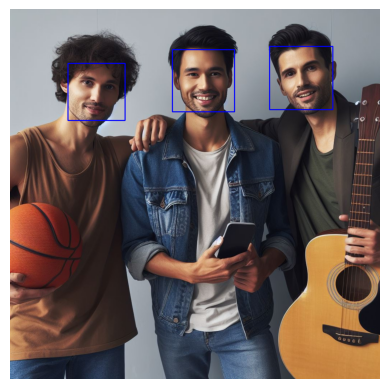

In [6]:
for (x,y,w,h) in faces:
    cv2.rectangle(image, (x,y), (x+w, y+h),(255,0,0),2)

plt.imshow(cv2.cvtColor(image,cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

In [7]:
from IPython import display

import glob
import imageio
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import tensorflow_probability as tfp
import time

In [8]:
(train_images,_),(_,_)=tf.keras.datasets.mnist.load_data()

def preprocess_image(images):
    images=images.reshape((images.shape[0],28,28,1))/255.
    return np.where(images>.5,1.0,0.0).astype('float32')

train_images=preprocess_image(train_images)

train_shuffle=60000
batch_size=128

train_dataset=(tf.data.Dataset.from_tensor_slices(train_images).shuffle(train_shuffle).batch(batch_size))

In [9]:
class VAE(tf.keras.Model):
    def __init__(self, latent_dim):
        super(VAE, self).__init__()
        self.latent_dim = latent_dim
        self.encoder = tf.keras.Sequential(
            [
                tf.keras.layers.InputLayer(input_shape=(28,28,1)),
                tf.keras.layers.Flatten(),
                tf.keras.layers.Dense(512, activation='relu'),
                tf.keras.layers.Dense(512, activation='relu'),
                tf.keras.layers.Dense(latent_dim + latent_dim)
            ]
        )
        self.decoder = tf.keras.Sequential(
            [
                tf.keras.layers.InputLayer(input_shape=(latent_dim,)),
                tf.keras.layers.Dense(512, activation='relu'),
                tf.keras.layers.Dense(512, activation='relu'),
                tf.keras.layers.Dense(28*28*1),
                tf.keras.layers.Reshape(target_shape=(28,28,1))
            ]
        )

    def sample(self, eps=None):                    # 4칸 들여쓰기
        if eps is None:
            eps = tf.random.normal(shape=(100, self.latent_dim))   # shape=
        return self.decode(eps, apply_sigmoid=True)

    def encode(self, x):                           # 4칸 들여쓰기
        mean, logvar = tf.split(self.encoder(x), num_or_size_splits=2, axis=1)
        return mean, logvar

    def reparameterize(self, mean, logvar):        # 4칸 들여쓰기
        eps = tf.random.normal(shape=mean.shape)
        return eps * tf.exp(logvar * .5) + mean    # logvar * .5

    def decode(self, z, apply_sigmoid=False):      # 4칸 들여쓰기
        logits = self.decoder(z)
        if apply_sigmoid:
            probs = tf.sigmoid(logits)
            return probs
        return logits

In [10]:
optimizer = tf.keras.optimizers.Adam(4e-4)

def log_normal_pdf(sample, mean, logvar, raxis = 1):
    log2pi = tf.math.log(2. * np.pi)
    return tf.reduce_sum(
        -.5 * ((sample - mean) ** 2. * tf.exp(-logvar)+ logvar + log2pi),
          axis = raxis
          )

def compute_loss(model, x):
    mean, logvar = model.encode(x)
    z = model.reparameterize(mean, logvar)
    x_logit = model.decode(z)
    cross_ent = tf.nn.sigmoid_cross_entropy_with_logits(logits = x_logit, labels = x)
    logpx_z = -tf.reduce_sum(cross_ent, axis = [1,2,3])
    logpz = log_normal_pdf(z, 0., 0.)
    logqz_x = log_normal_pdf(z, mean, logvar)
    return -tf.reduce_mean(logpx_z + logpz -logqz_x)

@tf.function
def train_step(model, x, optimizer):
    with tf.GradientTape() as tape:
        loss = compute_loss(model, x)
    gradients = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))




In [11]:
epochs = 50

latent_dim = 2
num_examples_to_generate = 25

random_vector_for_generation = tf.random.normal(
    shape = [num_examples_to_generate, latent_dim]
)
model = VAE(latent_dim)

In [12]:
assert batch_size >= num_examples_to_generate
for test_batch in train_dataset.take(1):
    test_sample = test_batch[0:num_examples_to_generate, :,:,:]


In [13]:
def generate_and_save_images(model, epoch, test_sample):
    mean, logvar = model.encode(test_sample)
    z = model.reparameterize(mean, logvar)
    predictions = model.sample(z)
    fig = plt.figure(figsize = (4,4))

    for i in range(predictions.shape[0]):
        plt.subplot(5,5,i+1)
        plt.imshow(predictions[i,:,:,0], cmap = "gray")
        plt.axis("off")

    plt.savefig("image_at_epoch_{:04d}.png".format(epoch))
    plt.show()

Epoch: 50, time elapse for current epoch : -130.6917266845703, time:4.724907159805298


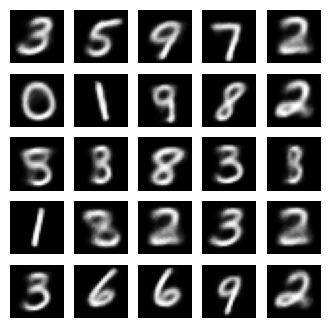

In [14]:
generate_and_save_images(model, 0, test_sample)

for epoch in range(1, epochs + 1):
    start_time = time.time()
    for train_x in train_dataset:
        train_step(model, train_x, optimizer)
    end_time = time.time()

    loss = tf.keras.metrics.Mean()
    for test_x in train_dataset:
        loss(compute_loss(model, test_x))

    elbo = -loss.result()

    display.clear_output(wait = False)
    print("Epoch: {}, time elapse for current epoch : {}, time:{}".format(epoch, elbo, end_time - start_time))
    generate_and_save_images(model, epoch, test_sample)

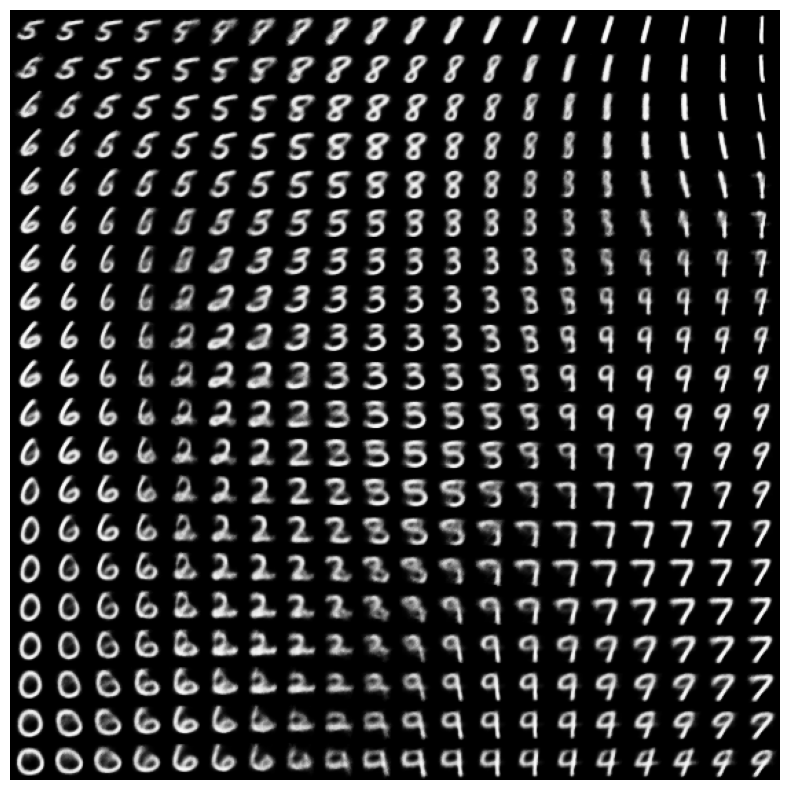

In [16]:
def plot_latent_images(model, n, digit_size = 28):
    norm = tfp.distributions.Normal(0, 1)
    grid_x = norm.quantile(np.linspace(0.05, 0.95, n))
    grid_y = norm.quantile(np.linspace(0.05, 0.95, n))
    image_width = digit_size * n
    image_height = image_width
    image = np.zeros((image_height, image_width))

    for i, yi in enumerate(grid_x):
        for j, xi, in enumerate(grid_y):
            z = np.array(
                [[xi, yi]]
            )
            x_decoded = model.sample(z)
            digit = tf.reshape(x_decoded[0], (digit_size, digit_size))
            image[i * digit_size: (i + 1) * digit_size,
                  j * digit_size: (j + 1) * digit_size] = digit.numpy()

    plt.figure(figsize = (10, 10))
    plt.imshow(image, cmap = "Greys_r")
    plt.axis("off")
    plt.show()


plot_latent_images(model, 20)